In [1]:
import logging
from loguru import logger
import sys

logging.basicConfig(level=logging.ERROR)
logger.remove()
logger.add(sys.stderr, level="ERROR")



1

Problem (training_together): Put it together (4 points)

Deliverable: Write a script that runs a training loop to train your model on user-provided input.

In particular, we recommend that your training script allow for (at least) the following:

- Ability to configure and control the various model and optimizer hyperparameters.
- Memory-eﬀicient loading of training and validation large datasets with np.memmap.
- Serializing checkpoints to a user-provided path.
- Periodically logging training and validation performance (e.g., to console and/or an external service like Weights and Biases)
- Every few iterations of training, output the predicted text (and decode it)


TODO: the tiktoken is currently set with a 50k vocab size ... we should set up a 10k vocab size as this will speed things
up.  See ron_bpe.py for example of 10k tokenizer.

We have a transformer language model that we will use a couple ways here.
1. We will trian it by feeding to batches of our trianing corpus, and evaluating the 
quality of the predictions
2. Every N iterations, we will provide it a "test-prompt" and let it tell us a little story.

prompt = tokenize("The ")
story = [prompt[0],]

for i in range(num_tok_stroy):
  output = ltm.forwrd(prompt)
  next_word = get_next_word(output) # 
  prompt = tokenize(next_word)
  story.append(next_word)


## Model and Optimizer parameter specification

In [2]:
import numpy as np
import pathlib
import torch
from torchview import draw_graph
from cs336_basics.slamkin_bpe import convert_text_to_bpe
from cs336_basics.train_bpe import DEFAULT_SPECIAL_TOKENS
import tiktoken
from cs336_basics.modules import AdamW
from cs336_basics.modules import TransformerLanguageModel
from cs336_basics.modules import cross_entropy
from cs336_basics.modules import get_batch
from cs336_basics.modules import save_checkpoint
from cs336_basics.modules import load_checkpoint


encoding_name = "r50k_base"
tokenizer = tiktoken.get_encoding(encoding_name)



data folder = /Users/kkappler/software/sound_thinking/stanford_cs/cs336-assignment1-basics/data


In [3]:
output = tokenizer.encode("Hello world!", allowed_special={'<|endoftext|>'})
print(output)
round_trip = tokenizer.decode(output)
print(round_trip)

[15496, 995, 0]
Hello world!


In [4]:
test_data = pathlib.Path("../data/test_timely_story.txt")
assert test_data.exists(), "Test data file does not exist. Please check the path."

# test_data = pathlib.Path("../data/TinyStoriesV2-GPT4-train.txt")
# assert test_data.exists(), "Test data file does not exist. Please check the path."

In [5]:
vocab_size = tokenizer.n_vocab  # 50257  # 10000  #50257,  # 50257 is the vocab size of the r50k_base tokenizer
context_length = 256  # 1024
num_layers = 4  # 48
d_model = 512  # 1600
num_heads = 16  #25
d_ff = 1344  # 6400
rope_theta = 10000

learning_rate = 1e-3 
learning_rate_warmup = 10  # 1000
adamw_betas = (0.9, 0.999)
adamw_eps = 1e-8
weight_decay = 0.01

num_batches_for_training = 4

token_dtype = np.uint16

# training_data_path = "data/processed/train.bin"


In [6]:
# This takes 7 minutes to run on my machine, which is a bit long for a test, 

# n = convert_text_to_bpe(
#     test_data, 
#     special_tokens=DEFAULT_SPECIAL_TOKENS,
#     output_path=f"data/processed/tiny_stories_with_{encoding_name}.memmap",
#     dtype=token_dtype
#     )

In [7]:
tokenized_training_data = "tiny_stories_tokenized_with_r50k_base_tiktoken.memmap"
# print(f"encoded with {n} tokens")
tokenized_text = np.memmap(tokenized_training_data, dtype=token_dtype) # , dtype=np.int32)
print(f"output shape: {tokenized_text.shape}, dtype: {tokenized_text.dtype}, first 100 tokens: {tokenized_text[:100]}")


output shape: (547725817,), dtype: uint16, first 100 tokens: [  198  7454  2402   257   640   612   373   257  1310  2933  3706  3932
    13  3932  6151   284  7301   262   995  1088   683    13   679  2497
   867  4998  1243    11   588  4950   410  1386   326   547   319  3359
   287   257  3650    13  1881  1110    11  3932   373  6155   832   262
  3650   618   339  1625  1973   257   845  2041   410   589    13  1649
  3932  2497   340   339   373 24562     0   220   220   198  1544   531
    11   564   250 22017    11   326   318   257  1107  4998   410   589
     0  1680   314  2822   340    30   447   251   220   198   464  6128
 13884 13541   290   531]


In [8]:
# len(np.unique(tokenized_text[:100]))

In [9]:

for i in range(11):
    print(f"{tokenized_text[i]}: '{tokenizer.decode([tokenized_text[i]])}'")

print(tokenizer.decode(tokenized_text[:11]))

198: '
'
7454: 'Once'
2402: ' upon'
257: ' a'
640: ' time'
612: ' there'
373: ' was'
257: ' a'
1310: ' little'
2933: ' boy'
3706: ' named'

Once upon a time there was a little boy named


In [10]:
rope_params = {
    'theta': rope_theta,
    "max_seq_len": context_length
}   
tlm = TransformerLanguageModel(
    vocab_size=vocab_size,
    num_layers=num_layers,
    d_model=d_model,
    num_heads=num_heads,
    d_ff=d_ff,
    rope_params=rope_params, 
    max_seq_len=context_length, # should be redundant with rope_params
)

In [11]:
sampled_input_sequences = [tokenizer.encode("The cat sat on the mat. The dog", allowed_special={'<|endoftext|>'})]
sampled_input_sequences
print(tokenizer.decode(sampled_input_sequences[0]))

The cat sat on the mat. The dog


In [12]:
# we use these for training
sampled_input_sequences, predicted = get_batch(
    tokenized_text, 
    batch_size=num_batches_for_training, 
    context_length=context_length, 
    device="cpu",
    )

/Users/kkappler/software/sound_thinking/stanford_cs/cs336-assignment1-basics/cs336_basics/modules.py:1225: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:257.)
  sampled_inputs = torch.tensor(


In [13]:
print(sampled_input_sequences.shape)
#sampled_input_subsequences[0:2, :5]
sampled_input_subsequences = sampled_input_sequences[0:1, :11]
tokenizer.decode(sampled_input_subsequences[0].tolist())

i_tok = 33
for i in range(4):
    
    print(tokenizer.decode(sampled_input_sequences[i, :33].tolist()),"\n")

torch.Size([4, 256])
 friends did not want Sam to feel sad, but they did not know how to teach him their language. They tried to show Sam, but it was so hard that 

Whose ball is this?" Spot and his friends went to her and told her it was theirs. Mrs. Smith gave them the ball back and shared her toast with 

'm happy we shared my toy. It's fun to play together." Sam agreed and said, "Yes, it's more fun when we share." From that day 

 and make bubbles with the soap. They wash their hands very well, because they know that germs can make them sick.
"Look, mom, we have 



In [14]:
logits = tlm.forward(
    sampled_input_sequences,
    )
logits[0, -1, 0:30]
print(f" logits.shape: {logits.shape}"  ,"(batch, context_length, vocab_size)")


 logits.shape: torch.Size([4, 256, 50257]) (batch, context_length, vocab_size)


In [15]:
# next word for the first sequence in the batch, based on the last position in the context
i_batch = 0
# logits[i_batch, -1, :].shape
next_token = logits[i_batch, -1, :].argmax().item()
print(f"Next token ID: {next_token}, which decodes to: '{tokenizer.decode([next_token])}'")

Next token ID: 20881, which decodes to: ' inflammation'


In [16]:
# here are the probabilities of the next word being each of the first 30 tokens in the vocabulary
# torch.softmax(logits[0, -1, :], dim=-1)[:30]
# TODO: study this later

In [35]:
test_prompt = "What are you doing today?"

In [36]:
def tell_me_a_little_story(prompt, tlm, tokenizer, max_length=50):
    input_ids = tokenizer.encode(prompt, allowed_special={'<|endoftext|>'})
    input_ids = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0)  # shape (1, seq_len)
    
    for _ in range(max_length):
        with torch.no_grad():
            logits = tlm.forward(input_ids)
        # next_token_id = logits[0, -1, :].argmax().item()
        next_token_id = torch.multinomial(torch.softmax(logits[0, -1, :], dim=-1), num_samples=1).item()
        input_ids = torch.cat([input_ids, torch.tensor([[next_token_id]], dtype=torch.long)], dim=1)
        
        #if next_token_id == tokenizer.eot_token_id:
        #    break
    
    story = tokenizer.decode(input_ids[0].tolist())
    print("\n".join(story[i:i+120] for i in range(0, len(story), 120)))
    return story

In [41]:

tell_me_a_little_story(test_prompt, tlm, tokenizer)
tell_me_a_little_story("2+2=", tlm, tokenizer)

What are you doing today? I am scared. You will settle until you areBu good," Momila said.
Lily and Jane walked to it. T
hey looked very scar. She saw if her dad was soldiers and ran. She bought it back for it. She ran
2+2=’t stayed. 
As Jane got home, he climbed down, Spot stepped down to the sky to see him melted. As they got up, it wa
s no more strong. As they left the street, the broken box won, and


'2+2=’t stayed. \nAs Jane got home, he climbed down, Spot stepped down to the sky to see him melted. As they got up, it was no more strong. As they left the street, the broken box won, and'

## Load best model to date

In [42]:
# TODO warm up adam: warmup_steps=learning_rate_warmup,
adamw_optimizer = AdamW(
    params=tlm.parameters(),
    lr=learning_rate,
    betas=adamw_betas,
    eps=adamw_eps,
    weight_decay=weight_decay,
)
adamw_optimizer.zero_grad()  # zero out gradients before training loop

checkpoint_fname = f"checkpoint_step_911_loss.pt"
#use_checkpoint_iter=276
if checkpoint_fname is not None:
    start_iteration = load_checkpoint(checkpoint_fname, tlm, adamw_optimizer)
    initial_loss = 2.84
    print(f"Resuming training from iteration {start_iteration} with initial loss {initial_loss:.4f}")
else:
    start_iteration = 0
    initial_loss = 100.0


Resuming training from iteration 911 with initial loss 2.8400


In [ ]:
tell_me_a_little_story(test_prompt, tlm, tokenizer, max_length=context_length)
tell_me_a_little_story("why not?", tlm, tokenizer, max_length=context_length)

## resume training loop

In [39]:

num_training_steps = 128001
next_story_step = 1 # 2**torch.arange(10)
initial_loss = 100.0


for i_step in range(start_iteration, num_training_steps):
        
    sampled_input_sequences, targets = get_batch(
        tokenized_text,
        batch_size=num_batches_for_training,
        context_length=context_length,
        device="cpu",
        )
    logits = tlm.forward(
        sampled_input_sequences,
        )
    # Print the 5 most probable

    # print(f"Logits shape: {logits.shape}, Targets shape: {targets.shape}")
    #next_tokens = logits[:, -1, :].argmax().item()
    #print(f"next_tokens: {next_tokens}, logits shape: {logits.shape}, targets shape: {targets.shape}")
    # gpt fix for cross_entropy input types
    if not isinstance(targets, torch.Tensor):
        targets = torch.tensor(targets, dtype=torch.long)
    elif targets.dtype != torch.long:
        targets = targets.long()
    
    mean_loss = cross_entropy(logits, targets)

    if mean_loss.item() < initial_loss:
        initial_loss = mean_loss.item()
        print(f"New lowest loss at step {i_step}: {initial_loss:.4f}")
        save_checkpoint(
            model=tlm, 
            optimizer=adamw_optimizer, 
            iteration=i_step, 
            out=f"checkpoint_step_{i_step}_loss.pt"
            ) 
        tell_me_a_little_story(test_prompt, tlm, tokenizer, max_length=context_length)


    adamw_optimizer.zero_grad()
    # TODO: backpropagate to update the model parameters using optimizers like AdamW
    mean_loss.backward()  # calculates gradients and stores them in the .grad attribute of each parameter
    # This shows what grad does: https://colab.research.google.com/drive/1OhZJs-zXCevwwvXYtbnqyy6mP-QIS_uk?hl=en#scrollTo=KgijKIe6dzpzcolab.research.google.comGoogle Colab
    adamw_optimizer.step()  # update
    
    if i_step == next_story_step:
        print(f"\n--- Story at step {i_step} --- (mean loss: {mean_loss.item():.4f})")
        tell_me_a_little_story(test_prompt, tlm, tokenizer)
        next_story_step *= 2



Resuming training from iteration 736 with initial loss 2.8900
New lowest loss at step 748: 2.8382
What are you doing today? It said, "Sue, I'll have a magic paint with her smile."
Tim and his mom smile and smelled enem
ies new things. They are happy. They ignored her shells together. They are very brave.
<|endoftext|>
Once upon a time, t
here was a little boy named Ben. Tom had many toys. One day, he jogging. He would run on his veil and ran to his window.
 One day, his mom went to the, so to play with joy.
Tim met his friendNo, and Max had a new idea. He his mom was so disa
ppointed, and he could find her run.
The little boy said, "This lost talents! I see the tree with its mouth." He smiled 
at Tim and said, "Yes, I will help you! I like your special power. I want to be scared again!" He became both very surpr
ised.
<|endoftext|>
One day, a big top. He liked to fix his backyard and sat down. One day, he found some of different s
weets.
One day, something strange item can be brave and

KeyboardInterrupt: 

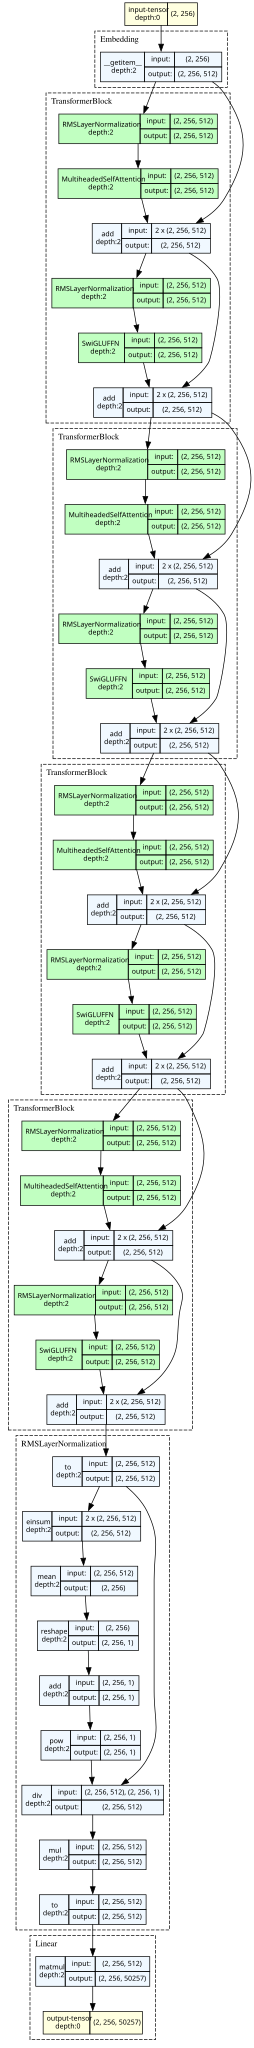

In [34]:
batch_size = 2
tmp = draw_graph(
    tlm, 
    input_data=torch.randint(0, vocab_size, (batch_size, context_length)),
    depth=2, # how many layers of the model to show in the graph. 2 is enough to see the attention and feedforward submodules, without making the graph too cluttered   
    expand_nested=True, # whether to expand nested modules like the attention and feedforward submodules into their own nodes in the graph. This can make the graph more detailed but also more cluttered, so we set it to True here since we are only showing 2 layers
    hide_inner_tensors=True, # whether to hide inner tensors in the graph. This can make the graph less cluttered and easier to read, especially for large models, so we set it to True here
    roll=True, # whether to roll the graph to make it more compact. This can make the graph easier to read and fit on the screen, especially for large models, so we set it to True here
    hide_module_functions=False
    )
tmp.visual_graph

In [ ]:
#mean_loss.backward?

Signature:
mean_loss.backward(
    gradient=None,
    retain_graph=None,
    create_graph=False,
    inputs=None,
)
Docstring:
Computes the gradient of current tensor wrt graph leaves.

The graph is differentiated using the chain rule. If the tensor is
non-scalar (i.e. its data has more than one element) and requires
gradient, the function additionally requires specifying a ``gradient``.
It should be a tensor of matching type and shape, that represents
the gradient of the differentiated function w.r.t. ``self``.

This function accumulates gradients in the leaves - you might need to zero
``.grad`` attributes or set them to ``None`` before calling it.
See :ref:`Default gradient layouts<default-grad-layouts>`
for details on the memory layout of accumulated gradients.

.. note::

    If you run any forward ops, create ``gradient``, and/or call ``backward``
    in a user-specified CUDA stream context, see
    :ref:`Stream semantics of backward passes<bwd-cuda-stream-semantics>`.

.. note::


In [ ]:
# # Aply softmax to the logits to get probabilities, and then take the argmax to get the predicted token ids
# print(f"logits shape:  {logits.shape}")
# # To avoid numerical instability, we can subtract the max logit before softmax
# max_logit = torch.max(logits, dim=-1, keepdim=True).values
# shifted_logits = logits - max_logit  # shape (..., seq_len, vocab_size)
# target_log_prob = shifted_logits.gather(
#         dim=-1, index=targets.unsqueeze(-1)
#     ).squeeze(
#         -1
#     )  # shape (..., seq_len)

# exp_logits = torch.exp(shifted_logits)  # shape (..., seq_len, vocab_size)
    
# sum_exp_logits = torch.sum(exp_logits, dim=-1, keepdim=True)  #
# print(f"logits shape: {logits.shape}")
# predicted = torch.argmax(logits, dim=-1)

# print(f"predicted shape: {predicted.shape}")

In [ ]:
predicted.shape

torch.Size([4, 256])

In [ ]:
# for i trg_cycle in num_training_cycles:
#     for j in range(num_batches_per_cycle):
#         batch = get_batch(tokenized_training_data, batch_size, context_length)
#         loss = tlm(batch)